# Flight Booking Analysis

# Project Summary

This notebook performs an exploratory data analysis of flight booking data to identify trends, analyze revenue distribution across fare conditions and aircraft, and assess aircraft utilization through occupancy rates. It also includes a hypothetical scenario to project potential revenue increase with improved occupancy.

In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
db_path = '/content/drive/MyDrive/practice_db/travel.sqlite'
conn = sqlite3.connect(db_path)

In [ ]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)
print(tables)

              name
0   aircrafts_data
1    airports_data
2  boarding_passes
3         bookings
4          flights
5            seats
6   ticket_flights
7          tickets


In [ ]:
tables_list = tables['name'].tolist()

for table in tables_list:
    print(f"--- Table: {table} ---")

    schema_info = pd.read_sql_query(f"PRAGMA table_info({table})", conn)

    print(schema_info[['name', 'type']])
    print("\n")

--- Table: aircrafts_data ---
            name          type
0  aircraft_code  character(3)
1          model         jsonb
2          range       INTEGER


--- Table: airports_data ---
           name          type
0  airport_code  character(3)
1  airport_name         jsonb
2          city         jsonb
3   coordinates         point
4      timezone          TEXT


--- Table: boarding_passes ---
          name                  type
0    ticket_no         character(13)
1    flight_id               INTEGER
2  boarding_no               INTEGER
3      seat_no  character varying(4)


--- Table: bookings ---
           name                      type
0      book_ref              character(6)
1     book_date  timestamp with time zone
2  total_amount             numeric(10,2)


--- Table: flights ---
                  name                      type
0            flight_id                   INTEGER
1            flight_no              character(6)
2  scheduled_departure  timestamp with time zone
3 

In [ ]:
tables_list = tables['name'].tolist()

for table_check in tables_list:
  query = f"""
  SELECT * FROM {table_check}
  """

  print('--- Table: '+ table_check +' ---')
  df = pd.read_sql_query(query, conn)

  print(df.isnull().sum())
  print('\n')

--- Table: aircrafts_data ---
aircraft_code    0
model            0
range            0
dtype: int64


--- Table: airports_data ---
airport_code    0
airport_name    0
city            0
coordinates     0
timezone        0
dtype: int64


--- Table: boarding_passes ---
ticket_no      0
flight_id      0
boarding_no    0
seat_no        0
dtype: int64


--- Table: bookings ---
book_ref        0
book_date       0
total_amount    0
dtype: int64


--- Table: flights ---
flight_id              0
flight_no              0
scheduled_departure    0
scheduled_arrival      0
departure_airport      0
arrival_airport        0
status                 0
aircraft_code          0
actual_departure       0
actual_arrival         0
dtype: int64


--- Table: seats ---
aircraft_code      0
seat_no            0
fare_conditions    0
dtype: int64


--- Table: ticket_flights ---
ticket_no          0
flight_id          0
fare_conditions    0
amount             0
dtype: int64


--- Table: tickets ---
ticket_no       0


## Basic EDA

This section performs basic exploratory data analysis on the flight booking dataset.

First, let's analyze the `ticket_flights` table to understand fare conditions, ticket counts, and revenue distribution.

### Fare Conditions Revenue Distribution

In [ ]:
query = """
SELECT fare_conditions,
       COUNT(*) AS ticket_count,
       SUM(amount) AS total_revenue,
       ROUND(AVG(amount), 2) AS avg_ticket_price,
       ROUND(SUM(amount) * 100.0 / SUM(SUM(amount)) OVER(), 2) AS revenue_share_pct
FROM ticket_flights
GROUP BY fare_conditions
ORDER BY total_revenue DESC
"""

pd.read_sql_query(query, conn)

,fare_conditions,ticket_count,total_revenue,avg_ticket_price,revenue_share_pct
0,Economy,920793,14695684400,15959.81,70.76
1,Business,107642,5505179600,51143.42,26.51
2,Comfort,17291,566116900,32740.55,2.73


The query results show that 'Economy' class tickets account for the majority of ticket sales and revenue, followed by 'Business' and then 'Comfort'. Economy class has the highest ticket count, while Business class has a significantly higher average ticket price, contributing a substantial portion to the total revenue despite fewer tickets.

### Daily ticket vooking trends

In [ ]:
query = """
SELECT * FROM tickets
INNER JOIN bookings
ON tickets.book_ref = bookings.book_ref
"""
df = pd.read_sql_query(query, conn)

df['book_date'] = pd.to_datetime(df['book_date'])

df['date'] = df['book_date'].dt.date

df.head()

,ticket_no,book_ref,passenger_id,book_ref,book_date,total_amount,date
0,0005432000987,06B046,8149 604011,06B046,2017-07-05 20:19:00+03:00,12400,2017-07-05
1,0005432000988,06B046,8499 420203,06B046,2017-07-05 20:19:00+03:00,12400,2017-07-05
2,0005432000989,E170C3,1011 752484,E170C3,2017-06-29 01:55:00+03:00,24700,2017-06-29
3,0005432000990,E170C3,4849 400049,E170C3,2017-06-29 01:55:00+03:00,24700,2017-06-29
4,0005432000991,F313DD,6615 976589,F313DD,2017-07-03 04:37:00+03:00,30900,2017-07-03


To analyze daily booking trends, the `tickets` and `bookings` tables were joined. The `book_date` column was converted to datetime objects, and a new `date` column was extracted to aggregate bookings by day. This DataFrame (`df`) is now ready for time-series analysis.

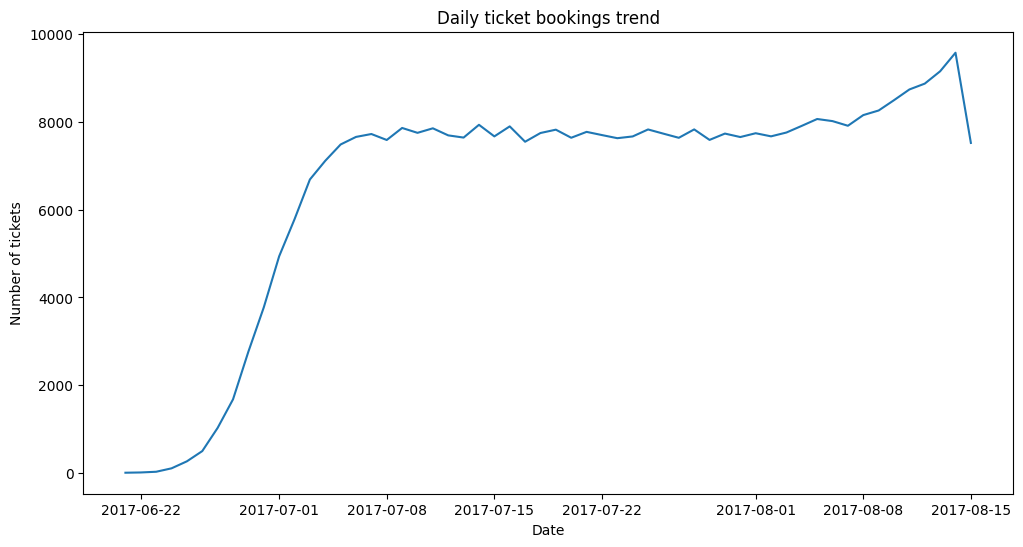

In [ ]:
a = df.groupby('date').size().reset_index(name='ticket_count') # Create a DataFrame with 'date' and 'ticket_count' columns

plt.figure(figsize = (12,6))
plt.title('Daily ticket bookings trend')
plt.plot(a['date'], a['ticket_count'])
plt.xlabel('Date')
plt.ylabel('Number of tickets')
plt.show()

The plot illustrates the daily trend of ticket bookings. We can observe fluctuations in the number of tickets booked each day, providing insights into peak booking periods or days with lower activity. This visualization helps in understanding the booking patterns over time.

### Average ticket price by aircraft and fare class

In [ ]:
query = """
SELECT aircraft_code, fare_conditions, avg(amount) AS avg_amount FROM ticket_flights
INNER JOIN flights
ON ticket_flights.flight_id = flights.flight_id
GROUP BY aircraft_code, fare_conditions
"""

b = pd.read_sql_query(query, conn)

This query calculates the average ticket price for each aircraft model across different fare conditions. By joining `ticket_flights` with `flights`, we can link ticket information to specific aircraft codes, enabling a detailed analysis of pricing strategies per aircraft type and fare class.

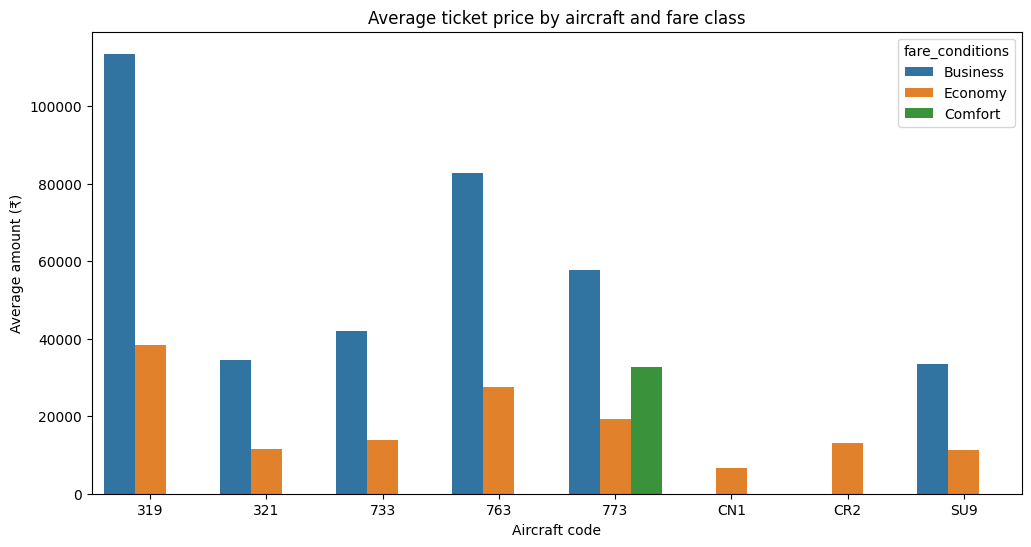

In [ ]:
plt.figure(figsize = (12,6))
plt.title('Average ticket price by aircraft and fare class')
sns.barplot(data = b, x = 'aircraft_code', y = 'avg_amount', hue = 'fare_conditions')
plt.xlabel('Aircraft code')
plt.ylabel('Average amount (₹)')
plt.show()

This bar chart effectively visualizes the average ticket price for various aircraft codes, broken down by fare conditions (Economy, Business, Comfort). It's evident that Business class tickets consistently command higher prices across all aircraft, with some aircraft like '773' showing particularly high average prices in premium classes. This helps identify which aircraft generate more revenue per ticket in different fare categories.

### Total revenue and average price per aircraft

In [ ]:
query = """
SELECT aircraft_code, ticket_count, total_revenue, total_revenue/ticket_count AS avg_price FROM
  (SELECT aircraft_code, count(*) AS ticket_count, sum(amount) AS total_revenue FROM ticket_flights
  INNER JOIN flights
  ON ticket_flights.flight_id = flights.flight_id
  GROUP BY aircraft_code)
"""

pd.read_sql_query(query, conn)

,aircraft_code,ticket_count,total_revenue,avg_price
0,319,52853,2706163100,51201
1,321,107129,1638164100,15291
2,733,86102,1426552100,16568
3,763,124774,4371277100,35033
4,773,144376,3431205500,23765
5,CN1,14672,96373800,6568
6,CR2,150122,1982760500,13207
7,SU9,365698,5114484700,13985


This table summarizes the total revenue generated and the average ticket price for each aircraft type. Aircraft '763' and '773' appear to be significant revenue generators, while '319' shows a high average price. This data is crucial for assessing the financial performance of different aircraft models.

In [ ]:
pd.options.display.float_format = '{:.2f}'.format

### Occupancy rate per aircraft

In [ ]:
query = """
SELECT A.aircraft_code, avg(total_seats_ocu) AS seats_booked, B.num_seats, avg(total_seats_ocu)/B.num_seats AS occupancy_rate FROM
  (SELECT aircraft_code, flights.flight_id, count(*) AS total_seats_ocu FROM boarding_passes
  INNER JOIN flights
  ON boarding_passes.flight_id = flights.flight_id
  GROUP BY aircraft_code, flights.flight_id) as A
  INNER JOIN
  (SELECT aircraft_code, count(*) AS num_seats FROM seats
  GROUP BY aircraft_code) as B
  ON A.aircraft_code = B.aircraft_code
  GROUP BY A.aircraft_code
"""

occupancy_table = pd.read_sql_query(query, conn)

occupancy_table

,aircraft_code,seats_booked,num_seats,occupancy_rate
0,319,53.58,116,0.46
1,321,88.81,170,0.52
2,733,80.26,130,0.62
3,763,113.94,222,0.51
4,773,264.93,402,0.66
5,CN1,6.00,12,0.50
6,CR2,21.48,50,0.43
7,SU9,56.81,97,0.59


This table provides insights into the average number of seats booked (`seats_booked`), the total number of seats (`num_seats`), and the actual occupancy rate for each aircraft type. The occupancy rate (average seats booked divided by total seats) helps identify how efficiently each aircraft is being utilized.

### Hypothetical 10% increase in occupancy rate

To simulate potential improvements, a new column `exp_occupancy_rate` has been added, representing a 10% increase over the current occupancy rate. This hypothetical increase will be used to calculate the 'expected turnover'.

In [ ]:
occupancy_table['exp_occupancy_rate'] = occupancy_table['occupancy_rate'] * 1.1

occupancy_table

,aircraft_code,seats_booked,num_seats,occupancy_rate,exp_occupancy_rate
0,319,53.58,116,0.46,0.51
1,321,88.81,170,0.52,0.57
2,733,80.26,130,0.62,0.68
3,763,113.94,222,0.51,0.56
4,773,264.93,402,0.66,0.72
5,CN1,6.00,12,0.50,0.55
6,CR2,21.48,50,0.43,0.47
7,SU9,56.81,97,0.59,0.64


In [ ]:
query = """
SELECT aircraft_code, sum(amount) AS total_revenue FROM ticket_flights
INNER JOIN flights
ON flights.flight_id = ticket_flights.flight_id
GROUP BY aircraft_code
"""

revenue_table = pd.read_sql_query(query, conn)
revenue_table

,aircraft_code,total_revenue
0,319,2706163100
1,321,1638164100
2,733,1426552100
3,763,4371277100
4,773,3431205500
5,CN1,96373800
6,CR2,1982760500
7,SU9,5114484700


This query retrieves the total revenue generated by each aircraft. This data is essential for calculating the `exp_turnover` by leveraging the total revenue and current / expected occupancy rates. Looking at the thable, the SU9 aircraft, despite having fewer seats (97) and an occupancy rate of 0.59, exhibits the highest total revenue. This suggests that the SU9 may operate a significantly higher number of flights compared to other aircraft types.

## Aircraft performance analysis

This section delves deeper into the performance of each aircraft model by analyzing various metrics such as total flights, total revenue, total tickets, and average ticket price. This analysis aims to explain the revenue distribution across different aircraft types and identify key contributors to overall profitability, especially for aircraft like 'SU9' which might show high revenue despite fewer seats.

In [ ]:
query = """
SELECT
    f.aircraft_code,
    COUNT(DISTINCT f.flight_id) AS total_flights,
    COUNT(tf.ticket_no) AS total_tickets_sold,
    SUM(tf.amount) AS total_revenue,
    ROUND(AVG(tf.amount), 2) AS avg_ticket_price,
    ROUND(SUM(tf.amount) /
          COUNT(DISTINCT f.flight_id), 2) AS revenue_per_flight
FROM flights f
JOIN ticket_flights tf ON tf.flight_id = f.flight_id
GROUP BY f.aircraft_code
ORDER BY total_flights DESC
"""

pd.read_sql_query(query, conn)

,aircraft_code,total_flights,total_tickets_sold,total_revenue,avg_ticket_price,revenue_per_flight
0,CR2,7424,150122,1982760500,13207.66,267074.0
1,SU9,6931,365698,5114484700,13985.54,737914.0
2,CN1,2542,14672,96373800,6568.55,37912.0
3,321,1294,107129,1638164100,15291.51,1265969.0
4,763,1195,124774,4371277100,35033.56,3657972.0
5,733,1164,86102,1426552100,16568.16,1225560.0
6,319,1067,52853,2706163100,51201.69,2536235.0
7,773,609,144376,3431205500,23765.76,5634163.0


This analysis provides a detailed breakdown of each aircraft's performance. It shows that while `CR2` has the highest number of flights, `SU9` leads in total revenue due to a significant number of tickets sold. Notably, `773` aircraft generate the highest revenue per flight, indicating high profitability per operation despite a lower total number of flights. `319` aircraft stand out with the highest average ticket price, suggesting a focus on premium fare classes. These metrics are crucial for understanding the overall contribution and efficiency of each aircraft type to the airline's operations.

In [ ]:
occupancy_table['exp_turnover'] = (revenue_table['total_revenue']/occupancy_table['occupancy_rate'])*occupancy_table['exp_occupancy_rate']

occupancy_table

,aircraft_code,seats_booked,num_seats,occupancy_rate,exp_occupancy_rate,exp_turnover
0,319,53.58,116,0.46,0.51,2976779410.00
1,321,88.81,170,0.52,0.57,1801980510.00
2,733,80.26,130,0.62,0.68,1569207310.00
3,763,113.94,222,0.51,0.56,4808404810.00
4,773,264.93,402,0.66,0.72,3774326050.00
5,CN1,6.00,12,0.50,0.55,106011180.00
6,CR2,21.48,50,0.43,0.47,2181036550.00
7,SU9,56.81,97,0.59,0.64,5625933170.00


This final table calculates the `exp_turnover` for each aircraft, based on the projected 10% increase in occupancy rate. The formula `(total_revenue / occupancy_rate) * exp_occupancy_rate` estimates the potential revenue if the occupancy rate were to improve as targeted. This provides a clear financial projection for optimizing aircraft utilization.

In [ ]:
query = """
SELECT aircraft_code, sum(amount) AS total_revenue FROM ticket_flights
INNER JOIN flights
ON flights.flight_id = ticket_flights.flight_id
GROUP BY aircraft_code
"""

x = pd.read_sql_query(query, conn)
x

,aircraft_code,total_revenue
0,319,2706163100
1,321,1638164100
2,733,1426552100
3,763,4371277100
4,773,3431205500
5,CN1,96373800
6,CR2,1982760500
7,SU9,5114484700


In [ ]:
query = """
SELECT
    f.aircraft_code,
    SUM(tf.amount) AS total_revenue_boarded_passengers
FROM ticket_flights tf
INNER JOIN boarding_passes bp
    ON tf.flight_id = bp.flight_id
    AND tf.ticket_no = bp.ticket_no
INNER JOIN flights f
    ON tf.flight_id = f.flight_id
GROUP BY f.aircraft_code
ORDER BY f.aircraft_code;
"""

boarded_revenue_df = pd.read_sql_query(query, conn)
boarded_revenue_df

,aircraft_code,total_revenue_boarded_passengers
0,319,1503777300
1,321,891268400
2,733,787683100
3,763,2402343500
4,773,1955244700
5,CN1,53786700
6,CR2,1106697500
7,SU9,2834608500


In [ ]:
boarded_revenue_df['difference'] = x['total_revenue'] - boarded_revenue_df['total_revenue_boarded_passengers']
boarded_revenue_df['differencr_pct'] = (boarded_revenue_df['difference']/x['total_revenue'])*100

boarded_revenue_df

,aircraft_code,total_revenue_boarded_passengers,difference,differencr_pct
0,319,1503777300,1202385800,44.431387
1,321,891268400,746895700,45.593460
2,733,787683100,638869000,44.784134
3,763,2402343500,1968933600,45.042525
4,773,1955244700,1475960800,43.015809
5,CN1,53786700,42587100,44.189500
6,CR2,1106697500,876063000,44.184005
7,SU9,2834608500,2279876200,44.576851


## Connection close

In [ ]:
conn.close()

# Conclusion

This analysis provided valuable insights into the flight booking data. We observed that Economy class tickets drive the majority of sales and revenue, while Business class generates higher average ticket prices. The daily booking trends showed fluctuations, indicating potential for demand forecasting.

Aircraft-specific analysis revealed significant revenue contributions from certain aircraft models and highlighted varying average ticket prices across fare classes. The occupancy rate analysis provided a measure of aircraft utilization, and the hypothetical 10% increase in occupancy rate demonstrated a clear potential for substantial revenue growth. These findings can inform strategic decisions related to pricing, fleet management, and marketing efforts to optimize revenue and efficiency.